# Motor de Inferencia Bayesiana
---
### Objetivo
**Construir un Motor de Inferencia Bayesiana capaz de realizar diagnósticos médicos secuenciales. El sistema debe calcular la probabilidad real de una enfermedad y actualizarla automáticamente a medida que el paciente se somete a múltiples pruebas.**

### Base Teórica
Para resolver esto, usaremos la forma extendida del Teorema de Bayes:
$$P(\text{Enfermo}|\text{Positivo}) = \frac{P(\text{Positivo}|\text{Enfermo}) \cdot P(\text{Enfermo})}{P(\text{Positivo})}$$
Donde la Evidencia $P(\text{Positivo})$ se calcula sumando dos caminos:
- Camino del enfermo que da positivo (Verdadero Positivo).
- Camino del sano que da positivo (Falso Positivo).

In [14]:
import numpy  as np 
import matplotlib.pyplot as plt 



## Escenario de simulacion

### Supuesto del problema
Diseñaremos una IA para detectar una patología específica (ej. una variante rara de un virus).

- Prevalencia ($\text{Prior}$): $1\%$. (Solo 1 de cada 100 personas la tiene).
- Prueba A (Rápida): Sensibilidad $95\%$, Especificidad $90\%$.
- Prueba B (Laboratorio): Sensibilidad $99\%$, Especificidad $98\%$.

In [15]:
def calcular_bayes(prior,sensibilidad, especificidad):

    # Calcular la probabilidad posterior usando el teorema de Bayes

    # P(A|B) = (P(B|A) * P(A)) / P(B)
    # P(B) = P(B|A) * P(A) + P(B|~A) * P(~A)
    


    #Probabilidad de dar positivo siendo positivo (Verdadero positivo)
    #P(B|A) * P(A) = sensibilidad * prior
    p_pos_enfermo = sensibilidad * prior

    #Probabilidad de dar positivo siendo sano (Falso positivo)
    #P(B|~A) * P(~A) = (1-especificidad) * (1-prior)
    p_pos_sano = (1-especificidad) * (1-prior)

    #Evidencia : Probabilidad total de que el test de positivo
    #P(B) = P(B|A) * P(A) + P(B|~A) * P(~A)
    evidencia = p_pos_enfermo + p_pos_sano
    
    #Teorema de Bayes: P(A|B) = (P(B|A) * P(A)) / P(B)
     
    posterior = p_pos_enfermo / evidencia

    return posterior




## Configuracion de escenario

In [16]:
prior_inicial = 0.01  #1% de prevalencia (creencia inicial)
sens_A , espec_A = 0.95 ,0.90 #Test A: 95% sensibilidad, 90% especificidad
sens_B , espec_B = 0.99 , 0.98 #Test B: 99% sensibilidad, 98% especificidad

## Ejecucion del escenario

In [17]:
#El paciente se somete al Test A y da positivo
posterior_A  = calcular_bayes(prior_inicial , sens_A , espec_A)

#El posterior del Test A se convierte en el prior del Test B 

posterior_B  = calcular_bayes(posterior_A, sens_B, espec_B)

print(f"Probabilidad de estar enfermo después del Test A: {posterior_A:.4f} ({posterior_A*100:.2f}%)")
print(f"Probabilidad de estar enfermo después del Test B: {posterior_B:.4f} ({posterior_B*100:.2f}%)")


Probabilidad de estar enfermo después del Test A: 0.0876 (8.76%)
Probabilidad de estar enfermo después del Test B: 0.8261 (82.61%)


## Visualizacion de la actualizacion de la creencia

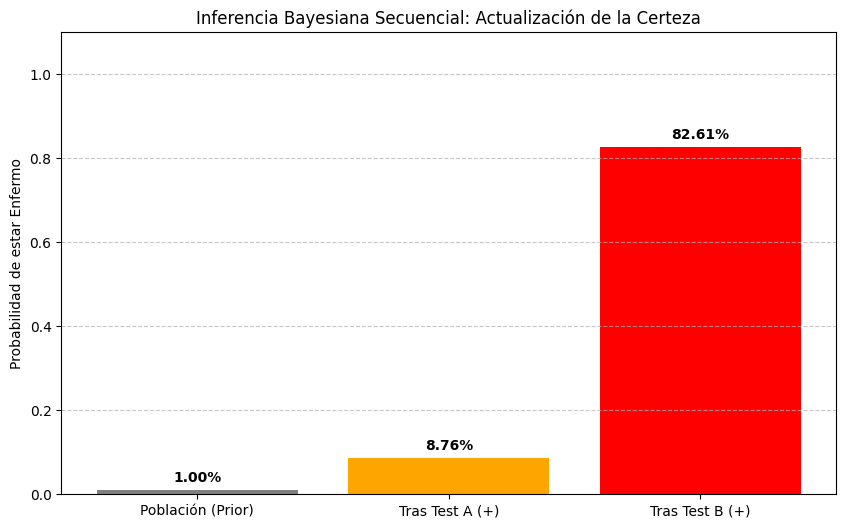

Probabilidad inicial (Prevalencia): 1.00%
Probabilidad tras Test A positivo: 8.76%
Probabilidad tras Test B positivo: 82.61%


In [18]:
etapas = ['Población (Prior)', 'Tras Test A (+)', 'Tras Test B (+)']
probabilidades = [prior_inicial, posterior_A, posterior_B]

plt.figure(figsize=(10, 6))
plt.bar(etapas, probabilidades, color=['gray', 'orange', 'red'])
plt.ylabel('Probabilidad de estar Enfermo')
plt.title('Inferencia Bayesiana Secuencial: Actualización de la Certeza')

# Añadir etiquetas de porcentaje
for i, v in enumerate(probabilidades):
    plt.text(i, v + 0.02, f"{v:.2%}", ha='center', fontweight='bold')

plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Probabilidad inicial (Prevalencia): {prior_inicial:.2%}")
print(f"Probabilidad tras Test A positivo: {posterior_A:.2%}")
print(f"Probabilidad tras Test B positivo: {posterior_B:.2%}")

## Hagamos una tercera prueba

Probabilidad tras Test C positivo: 0.9958 (99.58%)


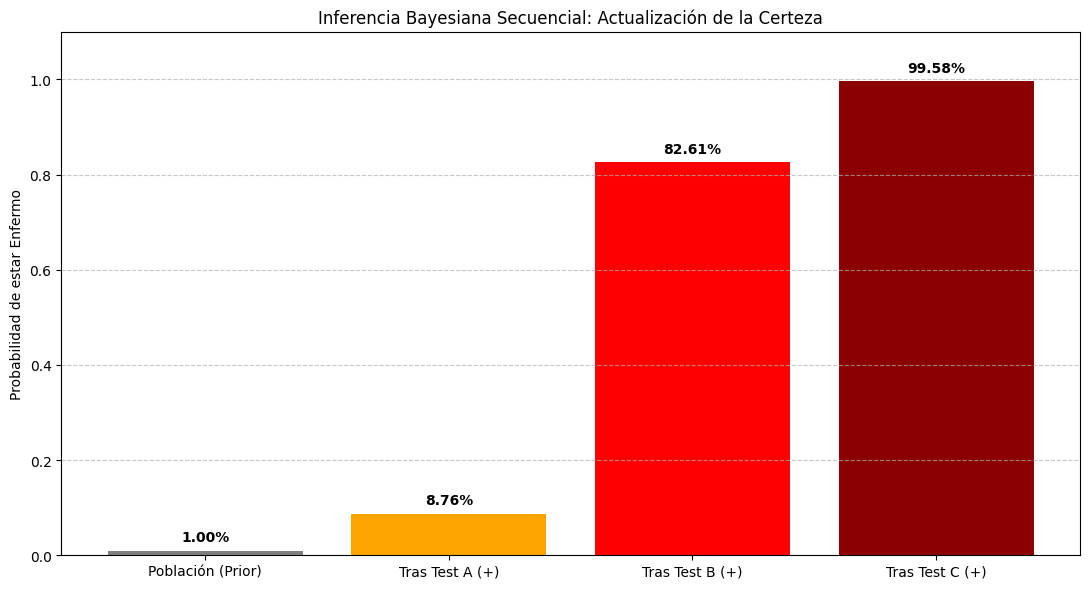

Probabilidad inicial (Prevalencia): 1.00%
Probabilidad tras Test A positivo: 8.76%
Probabilidad tras Test B positivo: 82.61%
Probabilidad tras Test C positivo: 99.58%


In [20]:
posterior_C = calcular_bayes(posterior_B, sens_B, espec_B)
print(f"Probabilidad tras Test C positivo: {posterior_C:.4f} ({posterior_C*100:.2f}%)")

etapas = ['Población (Prior)', 'Tras Test A (+)', 'Tras Test B (+)', 'Tras Test C (+)']
probabilidades = [prior_inicial, posterior_A, posterior_B, posterior_C]
colores = ['gray', 'orange', 'red', 'darkred']

plt.figure(figsize=(11, 6))
plt.bar(etapas, probabilidades, color=colores)
plt.ylabel('Probabilidad de estar Enfermo')
plt.title('Inferencia Bayesiana Secuencial: Actualización de la Certeza')

for i, v in enumerate(probabilidades):
    plt.text(i, v + 0.02, f"{v:.2%}", ha='center', fontweight='bold')

plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"Probabilidad inicial (Prevalencia): {prior_inicial:.2%}")
print(f"Probabilidad tras Test A positivo: {posterior_A:.2%}")
print(f"Probabilidad tras Test B positivo: {posterior_B:.2%}")
print(f"Probabilidad tras Test C positivo: {posterior_C:.2%}")

## Simulacion de Poblacion masiva

**Aquí veremos cuántas personas "sanas" terminan con un diagnóstico positivo (Falsos Positivos) y cuántas enfermas se nos escapan (Falsos Negativos).**

In [26]:
n_poblacion = 100000
prevalencia = 0.01  # 1% de prevalencia

# Crear poblacion simulada ( 0 = Sano , 1 = Enfermo)
# Usamos al distribucion de Bernoulli para simular la poblacion

estado_real = np.random.choice([0,1], size=n_poblacion, p=[1-prevalencia, prevalencia])

# Funcion para simular el resultado del test dado el estado real y las caracteristicas del test
#
def simular_test(estados ,sens ,espec ) :
    resultados = np.zeros_like(estados)
    for i in range(len(estados)) :
        prob = np.random.random()
        if estados[i] == 1 : #Si el individuo esta enfermo
            resultados[i] = 1 if prob < sens else 0
        else : #Si el individuo esta sano
            resultados[i] = 1 if prob > espec else 0
    return resultados

## Ejecucion del proceso de diagnostico

In [27]:
print("Iniciando simulacion de 100k Pacientes ---")

#Resultados del Test A
resultados_test_A =  simular_test(estado_real, 0.95 , 0.90)

#Filtramos solo a los que dieron positivo en el Test A

indices_positivos_A = np.where(resultados_test_A == 1)[0]
resultados_test_B = simular_test(estado_real[indices_positivos_A],0.99,0.98)

#Analisis de resultados finales

enfermos_reales_detectados = np.sum(estado_real[indices_positivos_A][resultados_test_B == 1])
total_positivos_B = np.sum(resultados_test_B)

precision_simulada = enfermos_reales_detectados / total_positivos_B if total_positivos_B > 0 else 0

print(f"\nResultados:")
print(f"Total de enfermos reales en la ciudad: {np.sum(estado_real)}")
print(f"Personas que dieron positivo en ambos tests: {total_positivos_B}")
print(f"De esos positivos, ¿cuántos están realmente enfermos?: {enfermos_reales_detectados}")
print(f"Precisión del sistema (Posterior empírico): {precision_simulada:.2%}")

Iniciando simulacion de 100k Pacientes ---

Resultados:
Total de enfermos reales en la ciudad: 987
Personas que dieron positivo en ambos tests: 1103
De esos positivos, ¿cuántos están realmente enfermos?: 932
Precisión del sistema (Posterior empírico): 84.50%
